![head.png](https://github.com/cafawo/FinancialDataAnalytics/blob/master/figures/head.jpg?raw=1)

# Financial Data Analytics in Python

**Prof. Dr. Fabian Woebbeking**</br>
Assistant Professor of Financial Economics

IWH - Leibniz Institute for Economic Research</br>
MLU - Martin Luther University Halle-Wittenberg

fabian.woebbeking@iwh-halle.de

# Homework: Satellite imagery

You will need a Git/GitHub repository to submit your course deliverables. Consult [**slides.ipynb**](https://github.com/cafawo/FinancialDataAnalytics) for help with the tasks below! If you need further assistance, do not hesitate to open a Q&A at https://github.com/cafawo/FinancialDataAnalytics/discussions

### Task:

Set up a google earth engine workflow to display satellite images of a location (or region) of your choosing.

In [1]:
# Packages used in this notebook

# !pip install ee
# !pip install geemap

import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import ee
ee.Authenticate()
ee.Initialize(project='ee-h2501296')
print(ee.String('Hello from the Earth Engine servers!').getInfo())

Hello from the Earth Engine servers!


**Retrieving data**

In [3]:
# Define the location and create a red box around it.
location_2022 = ee.Geometry.Point([33.34864, 46.75451]) # Nova Kakhovka, Ukraine
rectangle_2022 = location_2022.buffer(50).bounds()  # Buffer by 50m radius

In [4]:
# Load a high-resolution satellite image.
image_collection_2022 = ee.ImageCollection('COPERNICUS/S2_HARMONIZED') \
    .filterBounds(location_2022) \
    .filterDate('2022-01-01', '2022-12-31') \
    .sort('CLOUD_COVERAGE_ASSESSMENT', True)  # Sort by cloud coverage for clearer images


In [5]:
# Take the first image from the collection (least cloudy)
image_2022 = image_collection_2022.first()

In [6]:
# Display parameters
vis_params = {
    'bands': ['B4', 'B3', 'B2'],  # Red, Green, Blue
    'min': 0,
    'max': 3000,
    'gamma': 1.4
}

In [7]:
# Visualize the image with a red box.
Map_2022 = geemap.Map(center=[46.75451, 33.34864], zoom=11)
Map_2022.addLayer(image_2022, vis_params, 'RGB')
Map_2022.addLayer(rectangle_2022, {'color': 'red'}, 'Rectangle')
#Map_2022.centerObject(rectangle_2022)
Map_2022

Map(center=[46.75451, 33.34864], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [8]:
# For comparison: Nova Kakhovka in 2023 (after the attack on the dam and its destruction)
# using data from summer months (after the attack in June) to see how nature responded

# Define the location and create a red box around it.
location_2023 = ee.Geometry.Point([33.34864, 46.75451]) # Nova Kakhovka, Ukraine
rectangle_2023 = location_2023.buffer(50).bounds()  # Buffer by 50m radius

# Load a high-resolution satellite image.
image_collection_2023 = ee.ImageCollection('COPERNICUS/S2_HARMONIZED') \
    .filterBounds(location_2023) \
    .filterDate('2023-07-01', '2023-09-30') \
    .sort('CLOUD_COVERAGE_ASSESSMENT', True)  # Sort by cloud coverage for clearer images

# Take the first image from the collection (least cloudy)
image_2023 = image_collection_2023.first()

# Display parameters
vis_params = {
    'bands': ['B4', 'B3', 'B2'],  # Red, Green, Blue
    'min': 0,
    'max': 3000,
    'gamma': 1.4
}

# Visualize the image with a red box.
Map_2023 = geemap.Map(center=[46.75451, 33.34864], zoom=11)
Map_2023.addLayer(image_2023, vis_params, 'RGB')
Map_2023.addLayer(rectangle_2023, {'color': 'red'}, 'Rectangle')
#Map_2023.centerObject(rectangle_2023)
Map_2023

Map(center=[46.75451, 33.34864], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [9]:
# For comparison: Nova Kakhovka in 2025 (forest has recovered)
# using data from sumemr months again for comparison

# Define the location and create a red box around it.
location_2026 = ee.Geometry.Point([33.34864, 46.75451]) # Nova Kakhovka
rectangle_2026 = location_2026.buffer(50).bounds()  # Buffer by 50m radius

# Load a high-resolution satellite image.
image_collection_2026 = ee.ImageCollection('COPERNICUS/S2_HARMONIZED') \
    .filterBounds(location_2026) \
    .filterDate('2025-06-01', '2025-09-30') \
    .sort('CLOUD_COVERAGE_ASSESSMENT', True)  # Sort by cloud coverage for clearer images

# Take the first image from the collection (least cloudy)
image_2026 = image_collection_2026.first()

# Display parameters
vis_params = {
    'bands': ['B4', 'B3', 'B2'],  # Red, Green, Blue
    'min': 0,
    'max': 3000,
    'gamma': 1.4
}

# Visualize the image with a red box.
Map_2026 = geemap.Map(center=[46.75451, 33.34864], zoom=11)
Map_2026.addLayer(image_2026, vis_params, 'RGB')
Map_2026.addLayer(rectangle_2026, {'color': 'red'}, 'Rectangle')
#Map_2026.centerObject(rectangle_2026)
Map_2026

Map(center=[46.75451, 33.34864], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### Task:

Show a time series plot of the average summer temperature in celsius at your location. To do so, choose a relevant data sets from: https://developers.google.com/earth-engine/datasets/

In [ ]:
# Average yearly summer temperature in Nova Kakhovka, Ukraine, using ERA5

import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd

# My location
location_temp = ee.Geometry.Point([33.34864, 46.75451])

# Load ERA5 daily dataset
era5 = ee.ImageCollection('ECMWF/ERA5/DAILY') \
    .select('mean_2m_air_temperature') \
    .filter(ee.Filter.calendarRange(6, 8, 'month'))  # JJA


In [16]:
# Function to get yearly mean summer temperature
def get_yearly_mean(year):
    year = ee.Number(year)
    summer = era5.filter(ee.Filter.calendarRange(year, year, 'year'))
    mean_temp = summer.mean().reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=location_temp,
        scale=27830  # ERA5 native resolution
    ).get('mean_2m_air_temperature')
    return ee.Feature(None, {'year': year, 'temp': mean_temp})

In [ ]:
# Get data for each year
years = list(range(2020, 2026))
features = ee.FeatureCollection([get_yearly_mean(y) for y in years])

In [19]:
# Check available date range first
print(era5.aggregate_min('system:time_start').getInfo())
print(era5.aggregate_max('system:time_start').getInfo())

297043200000
1594252800000


--> this means that the dataset only covers the years until 2020 --> not what I need!

In [22]:
# Trying a different dataset: ERA5-Land

collection = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
print(collection.aggregate_max('system:time_start').getInfo())
print(collection.first().bandNames().getInfo())

1781827200000
['dewpoint_temperature_2m', 'temperature_2m', 'skin_temperature', 'soil_temperature_level_1', 'soil_temperature_level_2', 'soil_temperature_level_3', 'soil_temperature_level_4', 'lake_bottom_temperature', 'lake_ice_depth', 'lake_ice_temperature', 'lake_mix_layer_depth', 'lake_mix_layer_temperature', 'lake_shape_factor', 'lake_total_layer_temperature', 'snow_albedo', 'snow_cover', 'snow_density', 'snow_depth', 'snow_depth_water_equivalent', 'snowfall_sum', 'snowmelt_sum', 'temperature_of_snow_layer', 'skin_reservoir_content', 'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2', 'volumetric_soil_water_layer_3', 'volumetric_soil_water_layer_4', 'forecast_albedo', 'surface_latent_heat_flux_sum', 'surface_net_solar_radiation_sum', 'surface_net_thermal_radiation_sum', 'surface_sensible_heat_flux_sum', 'surface_solar_radiation_downwards_sum', 'surface_thermal_radiation_downwards_sum', 'evaporation_from_bare_soil_sum', 'evaporation_from_open_water_surfaces_excluding_

In [23]:
# Load ERA5-Land daily dataset
era5 = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR') \
    .select('temperature_2m') \
    .filter(ee.Filter.calendarRange(6, 8, 'month'))  # JJA


In [24]:
# Function to get yearly mean summer temperature
def get_yearly_mean(year):
    year = ee.Number(year)
    summer = era5.filter(ee.Filter.calendarRange(year, year, 'year'))
    mean_temp = summer.mean().reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=location_temp,
        scale=11132  # ERA5-Land native resolution (~0.1°)
    ).get('temperature_2m')
    return ee.Feature(None, {'year': year, 'temp': mean_temp})


In [38]:
# Get data for each year
years = list(range(2016, 2026))
features = ee.FeatureCollection([get_yearly_mean(y) for y in years])

In [39]:
# Extract to pandas
data = features.getInfo()
records = [f['properties'] for f in data['features']]
df = pd.DataFrame(records)
df['temp_celsius'] = df['temp'] - 273.15  # Kelvin to Celsius
df = df.sort_values('year')

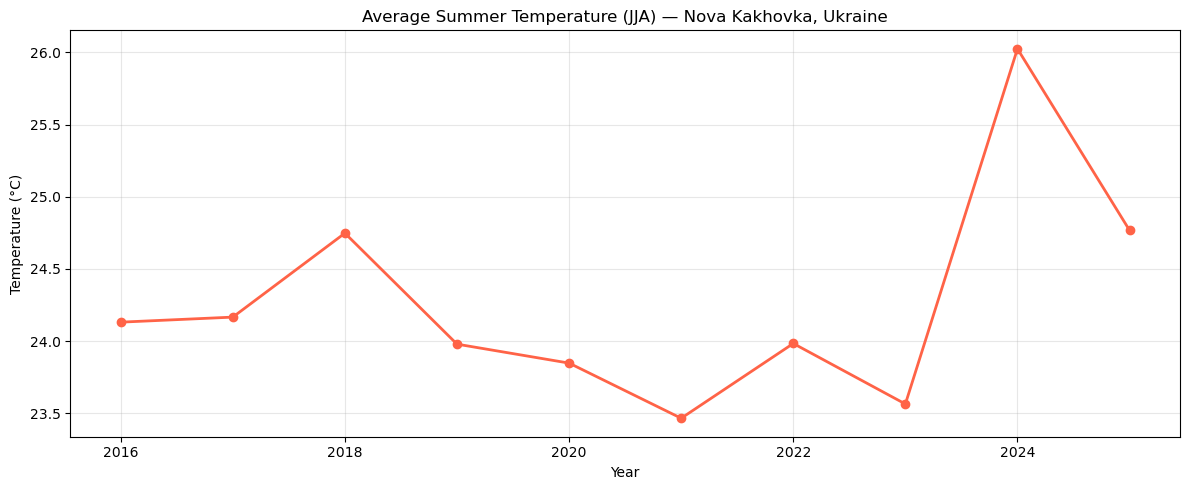

In [31]:
# Plot
plt.figure(figsize=(12, 5))
plt.plot(df['year'], df['temp_celsius'], marker='o', color='tomato', linewidth=2)
plt.title('Average Summer Temperature (JJA) — Nova Kakhovka, Ukraine')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The time series plot shows the average yearly temperature in Nova Kakhovka, Ukraine, for the years 2016 until 2025.
We can see that there is a strong correlation between the attack and destruction of the Nova Kakhovka dam in June 2023 (see second satellite image) and strongly rising temperatures in the following year 2024.
The falling temperatures in 2025 might be explained with the forest that started re-growing afterwards (see third satellite image).

The question remains why temperatures did not rise immediately after the destruction of the dam (in June 2023). We might, therefore, compare the months June-August 2023 to get more details.

Furthermore, rising temperatures might be a causal effect of wildfires as well.



### Task:

Discuss potential data quality issues and solutions. Do the results (temperatures) change if you employ a BAP composition? Add another line to the time series plot, displaying temperatures extracted from the BAP composites.